# Task 3: Revised Analysis with Time-Anchored AF Exposure

**Why this notebook exists.** Task 2 used the ICD code `I48.x` as the AF exposure with no timestamp. This causes two problems:
1. Cannot fix immortal-time bias in the Cox model (we don't know *when* AF appeared)
2. Mixes truly new-onset AF with chronic AF that happens to be coded this admission

This notebook rebuilds the AF exposure using **chartevents heart-rhythm records** (which have a precise timestamp), then re-runs the primary analysis on the **same 9,463 patients** selected by Task 2 / `cohort.Rmd`.

## What is different from Task 2

| Aspect | Task 2 | Task 3 (this notebook) |
|---|---|---|
| AF exposure | `has_af_index` (ICD I48 — no timestamp) | `has_af_chartevents` (rhythm record — has timestamp) |
| Cox model | Treats AF as baseline (immortal-time bias) | Time-varying: AF flips 0→1 at first rhythm record |
| Race | 5 levels | Binary White (ref) vs Non-White |
| Insurance | implicit reference | Medicare as explicit reference |
| HF subtype | 3 collinear dummies | Single 4-level factor (HFpEF as reference) |
| Mediators (24-h labs) | Included in Model 4 | Intentionally **excluded** from primary analysis |

## Sections
1. Load Task 2 cohort
2. Re-pull authoritative timestamps from `raw_data/`
3. Extract first AF rhythm time per stay
4. Chronic-AF proxy (flag, not exclusion)
5. Clean time-to-event variables
6. Primary logistic (Models 1–3)
7. Primary Cox (time-varying, 365-day horizon)
8. Headline summary table

In [1]:
import re
import warnings

import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from lifelines import CoxTimeVaryingFitter
from IPython.display import display

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.3f}'.format)

RAW   = 'raw_data'
CACHE = 'revision/cache'
OUT   = 'revision/output'

## Section 1 — Load Task 2 cohort

Inclusion / exclusion criteria from `cohort.Rmd` are kept exactly as-is — same 9,463 patients.

In [2]:
df = pd.read_csv('data/data.csv')
print(f'Cohort size: {len(df):,} patients')
print(f'In-hospital deaths (hospital_expire_flag): {df["hospital_expire_flag"].sum():,}')
print(f'ICD-AF prevalence (Task 2 exposure): {df["has_af_index"].mean():.1%}')

Cohort size: 9,463 patients
In-hospital deaths (hospital_expire_flag): 1,265
ICD-AF prevalence (Task 2 exposure): 39.9%


## Section 2 — Re-pull authoritative timestamps from raw_data/

`data/data.csv` has 2-digit year format that Python parses inconsistently. We re-pull from the gzipped raw tables. Patient set unchanged — only timestamps fixed.

In [3]:
drop_cols = ['admittime','dischtime','deathtime','icu_intime','icu_outtime','dod',
             'time_to_event_30d','censored_30d']
df = df.drop(columns=[c for c in drop_cols if c in df.columns])

adm = pd.read_csv(f'{RAW}/admissions.csv.gz',
                  usecols=['hadm_id','admittime','dischtime','deathtime'],
                  parse_dates=['admittime','dischtime','deathtime'])
icu = pd.read_csv(f'{RAW}/icustays.csv.gz',
                  usecols=['hadm_id','intime','outtime'],
                  parse_dates=['intime','outtime'])
icu = icu.sort_values(['hadm_id','intime']).groupby('hadm_id').first().reset_index()
icu = icu.rename(columns={'intime':'icu_intime','outtime':'icu_outtime'})
pat = pd.read_csv(f'{RAW}/patients.csv.gz',
                  usecols=['subject_id','dod'], parse_dates=['dod'])

df = (df.merge(adm, on='hadm_id', how='left')
        .merge(icu, on='hadm_id', how='left')
        .merge(pat, on='subject_id', how='left'))

print(f'After re-pulling timestamps: {len(df):,} patients (unchanged)')
print(f'admittime sample:  {df["admittime"].iloc[0]}')
print(f'icu_intime sample: {df["icu_intime"].iloc[0]}')

After re-pulling timestamps: 9,463 patients (unchanged)
admittime sample:  2200-09-30 14:00:00
icu_intime sample: 2200-10-01 08:42:08


## Section 3 — Extract first AF rhythm time per stay

From `chartevents itemid=220048` (Heart Rhythm), find the earliest record where value is `"AF (Atrial Fibrillation)"` or `"A Flut (Atrial Flutter)"`. This gives us a precise timestamp for AF onset.

Cache (~1.25 M rows) lives at `revision/cache/heart_rhythm.csv` — generated by `revision/01_build_analytic.py`.

In [4]:
rh = pd.read_csv(f'{CACHE}/heart_rhythm.csv', parse_dates=['charttime'])
print(f'Rhythm records pulled (itemid=220048): {len(rh):,}')
print('\nTop 8 rhythm values:')
print(rh['value'].value_counts().head(8).to_string())

AF_VALUES = {'AF (Atrial Fibrillation)', 'A Flut (Atrial Flutter)'}
rh['is_af'] = rh['value'].isin(AF_VALUES).astype(int)

Rhythm records pulled (itemid=220048): 1,252,586

Top 8 rhythm values:
value
SR (Sinus Rhythm)                  628202
AF (Atrial Fibrillation)           227614
ST (Sinus Tachycardia)             159584
V Paced                             59450
1st AV (First degree AV Block)      40097
SB (Sinus Bradycardia)              37866
AV Paced                            25064
A Flut (Atrial Flutter)             23356


In [5]:
rh_af = rh[rh['is_af'] == 1]
per_stay = pd.concat([
    rh.groupby('hadm_id')['charttime'].min().rename('first_rhythm_time'),
    rh_af.groupby('hadm_id')['charttime'].min().rename('first_af_time'),
    rh.groupby('hadm_id').size().rename('n_rhythm_records'),
    rh_af.groupby('hadm_id').size().rename('n_af_records'),
], axis=1).reset_index()
per_stay['has_af_chartevents'] = per_stay['first_af_time'].notna().astype(int)

df = df.merge(per_stay, on='hadm_id', how='left')
for c in ['has_af_chartevents','n_rhythm_records','n_af_records']:
    df[c] = df[c].fillna(0).astype(int)
df['hrs_to_first_af'] = (df['first_af_time'] - df['icu_intime']).dt.total_seconds() / 3600

print('AF exposure comparison:')
print(f'  ICD-AF (Task 2):           {df["has_af_index"].mean():.1%} of cohort')
print(f'  chartevents AF (Task 3):   {df["has_af_chartevents"].mean():.1%} of cohort\n')
print('Cross-tabulation (rows = ICD, cols = chartevents):')
print(pd.crosstab(df['has_af_index'].rename('ICD'),
                  df['has_af_chartevents'].rename('chartevents'), margins=True))

q = df.loc[df['has_af_chartevents']==1, 'hrs_to_first_af']
print('\nDistribution of hrs_to_first_af (chartevents-AF positives only):')
print(f'  N = {len(q):,}')
print(f'  median = {q.median():.1f} h')
print(f'  <=  0 h (already in AF on arrival): {(q<=0).mean():.1%}')
print(f'  <=  1 h:                            {(q<=1).mean():.1%}')
print(f'  <= 24 h:                            {(q<=24).mean():.1%}')
print(f'  >  48 h (true new-onset):           {(q>48).mean():.1%}')

AF exposure comparison:
  ICD-AF (Task 2):           39.9% of cohort
  chartevents AF (Task 3):   35.4% of cohort

Cross-tabulation (rows = ICD, cols = chartevents):
chartevents     0     1   All
ICD                          
0            5020   667  5687
1            1097  2679  3776
All          6117  3346  9463

Distribution of hrs_to_first_af (chartevents-AF positives only):
  N = 3,346
  median = 7.5 h
  <=  0 h (already in AF on arrival): 11.5%
  <=  1 h:                            35.9%
  <= 24 h:                            61.5%
  >  48 h (true new-onset):           25.0%


## Section 4 — Chronic-AF proxy (flag only, no exclusion)

Two signals (either one fires → `chronic_af_proxy = 1`):
1. AF on arrival — first AF rhythm ≤ 1 h after ICU intime
2. Home-AF medication — amiodarone / digoxin / sotalol etc. ordered ≤ 1 h after admittime

**No exclusion in main analysis** — this is just a transparency flag.

In [6]:
df['af_at_admission'] = (df['hrs_to_first_af'].fillna(np.inf) <= 1).astype(int)

pres = pd.read_csv(f'{CACHE}/prescriptions_af_drugs.csv', parse_dates=['starttime'])
AF_SPECIFIC_FLAGS = ['is_amiodarone','is_digoxin','is_sotalol','is_flecainide',
                     'is_propafenone','is_dofetilide','is_dronedarone']
pres['af_drug'] = pres[AF_SPECIFIC_FLAGS].sum(axis=1).clip(0,1)
pres = pres.merge(df[['hadm_id','admittime']], on='hadm_id', how='left')
pres['hrs_to_drug'] = (pres['starttime'] - pres['admittime']).dt.total_seconds() / 3600
early = (pres[(pres['af_drug']==1) & (pres['hrs_to_drug'] <= 1)]
         .groupby('hadm_id').size().rename('n_admit_af_drug').reset_index())

df = df.merge(early, on='hadm_id', how='left')
df['n_admit_af_drug']    = df['n_admit_af_drug'].fillna(0).astype(int)
df['af_drug_at_admit']   = (df['n_admit_af_drug'] > 0).astype(int)
df['chronic_af_proxy']   = ((df['af_at_admission']==1) | (df['af_drug_at_admit']==1)).astype(int)

print('Chronic-AF proxy components:')
print(f'  af_at_admission   (rhythm <= 1 h):  {df["af_at_admission"].mean():.1%}')
print(f'  af_drug_at_admit  (drug <= 1 h):    {df["af_drug_at_admit"].mean():.1%}')
print(f'  chronic_af_proxy  (either signal):  {df["chronic_af_proxy"].mean():.1%}')

Chronic-AF proxy components:
  af_at_admission   (rhythm <= 1 h):  12.7%
  af_drug_at_admit  (drug <= 1 h):    2.4%
  chronic_af_proxy  (either signal):  14.6%


## Section 5 — Clean time-to-event variables

Anchor t=0 at `icu_intime`. For each horizon h ∈ {30, 90, 180, 365 days}: `event_h_d`, `t2event_h_d` (1-hour floor).

In [7]:
df['days_to_death'] = (df['dod'] - df['icu_intime']).dt.total_seconds() / 86400
df['death_inhosp']  = ((df['deathtime'].notna()) &
                       (df['deathtime'] >= df['admittime']) &
                       (df['deathtime'] <= df['dischtime'])).astype(int)

HORIZONS = [30, 90, 180, 365]
HOUR = 1.0/24.0
for h in HORIZONS:
    days = df['days_to_death']
    ev = ((days >= 0) & (days <= h)).fillna(False).astype(int)
    t  = days.copy()
    t[~np.isfinite(t)] = h
    t = np.where(ev == 1, t, h)
    t = np.maximum(t, HOUR)
    t = np.minimum(t, h)
    df[f'event_{h}d']   = ev.astype(int)
    df[f't2event_{h}d'] = t

print('Outcome rates:')
print(f'  In-hospital mortality:   {df["death_inhosp"].mean():.1%}')
for h in HORIZONS:
    print(f'  {h}-day mortality:        {df[f"event_{h}d"].mean():.1%}')

Outcome rates:
  In-hospital mortality:   12.5%
  30-day mortality:        15.5%
  90-day mortality:        22.8%
  180-day mortality:        27.1%
  365-day mortality:        33.4%


## Section 6 — Primary logistic regression (Models 1–3)

Two key changes from Task 2:
1. **Exposure = `has_af_chartevents`** (rhythm-based, not ICD)
2. **Race** = binary `Non-White vs White` (White as reference)
3. **Insurance** = explicit `Medicare` as reference
4. **HF subtype** = single 4-level factor (HFpEF as reference) instead of 3 dummies

**Models** (each adds variables on top of the previous):
- **Model 1** — AF only (unadjusted)
- **Model 2** — + Demographics (age, sex, race, insurance)
- **Model 3 ⭐** — + HF subtype, comorbidities (10), ICU type   ← **fully adjusted, primary**

Mediator-adjusted (Task 2's Model 4) is intentionally **excluded** — 24-h labs/vitals are downstream of AF.

In [8]:
# Recode categorical variables
# Race : binary White (ref=0) vs Non-White (=1)
df['race_nonwhite'] = (~df['race'].astype(str).str.upper().str.startswith('WHITE')).astype(int)

# Insurance : 5 levels, Medicare as explicit reference
df['insurance_group'] = df['insurance'].fillna('Missing/Unknown')
ins_levels = ['Medicare'] + sorted([c for c in df['insurance_group'].unique() if c != 'Medicare'])
df['insurance_group'] = pd.Categorical(df['insurance_group'], categories=ins_levels)

df['female'] = (df['gender'] == 'F').astype(int)

# HF subtype : 4-level factor with HFpEF as reference
def recode_hf(row):
    if row['is_hfmixed'] == 1: return 'mixed'
    if row['is_hfref']   == 1 and row['is_hfpef'] == 0: return 'HFrEF'
    if row['is_hfpef']   == 1 and row['is_hfref'] == 0: return 'HFpEF'
    if row['is_hfref']   == 1 and row['is_hfpef'] == 1: return 'mixed'
    return 'unspecified'
df['hf_subtype'] = df.apply(recode_hf, axis=1)
obs_levels = [lv for lv in ['HFpEF','HFrEF','mixed','unspecified'] if lv in df['hf_subtype'].unique()]
df['hf_subtype'] = pd.Categorical(df['hf_subtype'], categories=obs_levels)

print('Race (White as reference):')
print(f'  White        (=0): {(df["race_nonwhite"]==0).sum():,} ({(df["race_nonwhite"]==0).mean():.1%})')
print(f'  Non-White    (=1): {(df["race_nonwhite"]==1).sum():,} ({(df["race_nonwhite"]==1).mean():.1%})')
print('\nInsurance distribution (Medicare = reference):')
print(df['insurance_group'].value_counts().to_string())
print('\nHF subtype distribution (HFpEF = reference):')
print(df['hf_subtype'].value_counts().to_string())

Race (White as reference):
  White        (=0): 6,197 (65.5%)
  Non-White    (=1): 3,266 (34.5%)

Insurance distribution (Medicare = reference):
insurance_group
Medicare           6606
Private            1610
Medicaid           1011
Other               160
Missing/Unknown      76

HF subtype distribution (HFpEF = reference):
hf_subtype
HFrEF    4553
HFpEF    4214
mixed     696


In [9]:
# Readable labels + helper
VAR_LABELS = {
    'has_af_chartevents':  'Atrial fibrillation (chartevents)',
    'age_at_admit':        'Age (per year)',
    'female':              'Female sex',
    'race_nonwhite':       'Race: Non-White (vs White)',
    'has_htn':'Hypertension','has_dm':'Diabetes mellitus','has_ckd':'Chronic kidney disease',
    'has_cad':'Coronary artery disease','has_copd':'COPD','has_valvular':'Valvular disease',
    'has_pad':'Peripheral arterial disease','has_stroke_hx':'Stroke / TIA history',
    'has_pulm_htn':'Pulmonary hypertension','has_cardiomyopathy':'Cardiomyopathy',
    'af_new_onset':        'Atrial fibrillation (new-onset only)',
}
def relabel(name):
    if name in VAR_LABELS: return VAR_LABELS[name]
    m = re.match(r'C\((\w+).*?\)\[T\.([^\]]+)\]', name)
    if m:
        var, lvl = m.group(1), m.group(2)
        var_pretty = {'insurance_group':'Insurance',
                      'careunit_cat':'ICU unit','hf_subtype':'HF subtype'}.get(var, var)
        return f'{var_pretty}: {lvl}'
    return name
def fit_logistic(formula, data, label):
    model = smf.logit(formula, data=data).fit(disp=0, maxiter=200)
    conf = model.conf_int()
    out = pd.DataFrame({
        'OR':    np.exp(model.params),
        'CI_lo': np.exp(conf[0]),
        'CI_hi': np.exp(conf[1]),
        'p-value': model.pvalues.apply(lambda p: f'{p:.3f}' if p>=0.001 else '<0.001'),
    })
    out['OR (95% CI)'] = out.apply(
        lambda r: f'{r["OR"]:.2f} ({r["CI_lo"]:.2f}\u2013{r["CI_hi"]:.2f})', axis=1)
    out.index = [relabel(i) for i in out.index]
    pseudo_r2 = 1 - (model.llf / model.llnull)
    print(f'{label}  N={int(model.nobs):,}  pseudo-R\u00b2={pseudo_r2:.3f}')
    display(out[['OR (95% CI)', 'p-value']])
    return model, out

In [10]:
needed_cols = ['has_af_chartevents','death_inhosp','age_at_admit','female','race_nonwhite','insurance_group',
               'has_htn','has_dm','has_ckd','has_cad','has_copd','has_valvular','has_pad',
               'has_stroke_hx','has_pulm_htn','has_cardiomyopathy','hf_subtype','careunit_cat']
df_cc = df.dropna(subset=needed_cols).copy()
print(f'Complete-case sample for primary logistic: {len(df_cc):,} (from {len(df):,})')

m1, r1 = fit_logistic('death_inhosp ~ has_af_chartevents',
                      df_cc, 'Model 1: Unadjusted')

m2, r2 = fit_logistic(
    'death_inhosp ~ has_af_chartevents + age_at_admit + female + '
    'race_nonwhite + C(insurance_group)',
    df_cc, 'Model 2: + Demographics')

m3, r3 = fit_logistic(
    'death_inhosp ~ has_af_chartevents + age_at_admit + female + '
    'race_nonwhite + C(insurance_group) + C(hf_subtype) + '
    'has_htn + has_dm + has_ckd + has_cad + has_copd + has_valvular + '
    'has_pad + has_stroke_hx + has_pulm_htn + has_cardiomyopathy + C(careunit_cat)',
    df_cc, 'Model 3: + Comorbidities + HF subtype + ICU (PRIMARY)')

Complete-case sample for primary logistic: 9,463 (from 9,463)


Model 1: Unadjusted  N=9,463  pseudo-R²=0.021


,OR (95% CI),p-value
Intercept,0.10 (0.10–0.11),<0.001
Atrial fibrillation (chartevents),2.14 (1.89–2.42),<0.001


Model 2: + Demographics  N=9,463  pseudo-R²=0.041


,OR (95% CI),p-value
Intercept,0.02 (0.01–0.03),<0.001
Insurance: Medicaid,0.69 (0.53–0.90),0.007
Insurance: Missing/Unknown,1.18 (0.58–2.42),0.648
Insurance: Other,0.36 (0.16–0.81),0.014
Insurance: Private,0.90 (0.73–1.11),0.336
Atrial fibrillation (chartevents),1.91 (1.69–2.17),<0.001
Age (per year),1.02 (1.02–1.03),<0.001
Female sex,0.94 (0.83–1.07),0.352
Race: Non-White (vs White),1.43 (1.25–1.62),<0.001


Model 3: + Comorbidities + HF subtype + ICU (PRIMARY)  N=9,463  pseudo-R²=0.064


,OR (95% CI),p-value
Intercept,0.01 (0.01–0.02),<0.001
Insurance: Medicaid,0.67 (0.52–0.88),0.004
Insurance: Missing/Unknown,1.29 (0.62–2.66),0.494
Insurance: Other,0.35 (0.15–0.81),0.014
Insurance: Private,0.95 (0.77–1.18),0.659
HF subtype: HFrEF,1.44 (1.25–1.67),<0.001
HF subtype: mixed,1.70 (1.34–2.15),<0.001
ICU unit: Medical,1.89 (1.63–2.19),<0.001
ICU unit: Surgical/Other,1.44 (1.18–1.75),<0.001
Atrial fibrillation (chartevents),1.96 (1.72–2.22),<0.001


In [11]:
# Logistic summary table
summary_log = pd.DataFrame({
    'Model': ['Model 1 (Unadjusted)', 'Model 2 (+Demographics)', 'Model 3 (Fully adjusted)'],
    'OR (95% CI)': [
        r1.loc['Atrial fibrillation (chartevents)','OR (95% CI)'],
        r2.loc['Atrial fibrillation (chartevents)','OR (95% CI)'],
        r3.loc['Atrial fibrillation (chartevents)','OR (95% CI)'],
    ],
    'p-value': [
        r1.loc['Atrial fibrillation (chartevents)','p-value'],
        r2.loc['Atrial fibrillation (chartevents)','p-value'],
        r3.loc['Atrial fibrillation (chartevents)','p-value'],
    ],
})
print('AF (chartevents) \u2192 in-hospital mortality, OR summary')
display(summary_log)

AF (chartevents) → in-hospital mortality, OR summary


,Model,OR (95% CI),p-value
0,Model 1 (Unadjusted),2.14 (1.89–2.42),<0.001
1,Model 2 (+Demographics),1.91 (1.69–2.17),<0.001
2,Model 3 (Fully adjusted),1.96 (1.72–2.22),<0.001


## Section 7 — Primary Cox: time-varying AF

Same adjustments as logistic Model 3. Each patient gets one or two rows (`[start, stop, af_status, event]`); AF flips 0→1 at first AF rhythm timestamp. Follow-up to 365 days.

In [12]:
COX_COVS = ['age_at_admit','female','has_htn','has_dm','has_ckd','has_cad','has_copd',
            'has_valvular','has_pad','has_stroke_hx','has_pulm_htn','has_cardiomyopathy',
            'is_hfref','is_hfmixed']  # HFpEF as reference
df['icu_cardiac']     = (df['careunit_cat']=='Cardiac').astype(int)         # vs Medical/Surgical
df['ins_nonmedicare'] = (df['insurance_group']!='Medicare').astype(int)     # Medicare as reference
COX_COVS += ['race_nonwhite','ins_nonmedicare','icu_cardiac']

df_cox = df.dropna(subset=COX_COVS).copy()
print(f'Cohort for Cox: {len(df_cox):,}')

Cohort for Cox: 9,463


In [13]:
# Build start/stop long-format dataset
HORIZON = 365
rows = []
for _, r in df_cox.iterrows():
    days = r['days_to_death']
    if pd.isna(days) or days > HORIZON:
        t_end, ev = HORIZON, 0
    elif days < 0:
        t_end, ev = HORIZON, 0
    else:
        t_end, ev = max(days, HOUR), 1
    af_days = r['hrs_to_first_af']/24 if pd.notna(r['hrs_to_first_af']) else np.inf
    base = {c: r[c] for c in COX_COVS}
    base['hadm_id'] = r['hadm_id']
    if af_days <= 0:
        rows.append({**base, 'start':0.0, 'stop':t_end, 'af_status':1, 'event':ev})
    elif np.isinf(af_days) or af_days >= t_end:
        rows.append({**base, 'start':0.0, 'stop':t_end, 'af_status':0, 'event':ev})
    else:
        rows.append({**base, 'start':0.0,     'stop':af_days, 'af_status':0, 'event':0})
        rows.append({**base, 'start':af_days, 'stop':t_end,   'af_status':1, 'event':ev})
long = pd.DataFrame(rows)
long = long[long['stop'] > long['start']].copy()

n_unique = long['hadm_id'].nunique()
n_2rows  = (long.groupby('hadm_id').size() == 2).sum()
n_1row   = (long.groupby('hadm_id').size() == 1).sum()
print(f'Long-format dataset: {len(long):,} rows from {n_unique:,} unique patients')
print(f'  Patients with 1 row (never-AF or AF-on-arrival): {n_1row:,}')
print(f'  Patients with 2 rows (AF flips during stay):     {n_2rows:,}')
print(f'  Events (deaths within {HORIZON} d): {long["event"].sum():,}')

Long-format dataset: 12,394 rows from 9,463 unique patients
  Patients with 1 row (never-AF or AF-on-arrival): 6,532
  Patients with 2 rows (AF flips during stay):     2,931
  Events (deaths within 365 d): 3,156


In [14]:
ctv = CoxTimeVaryingFitter(penalizer=0.001)
ctv.fit(long, id_col='hadm_id', event_col='event',
        start_col='start', stop_col='stop', show_progress=False)

cox_summary = ctv.summary.copy()
cox_summary['HR']    = np.exp(cox_summary['coef'])
cox_summary['HR_lo'] = np.exp(cox_summary['coef lower 95%'])
cox_summary['HR_hi'] = np.exp(cox_summary['coef upper 95%'])
cox_summary['HR (95% CI)'] = cox_summary.apply(
    lambda r: f'{r["HR"]:.2f} ({r["HR_lo"]:.2f}\u2013{r["HR_hi"]:.2f})', axis=1)
cox_summary['p-value'] = cox_summary['p'].apply(
    lambda p: f'{p:.3f}' if p>=0.001 else '<0.001')

VAR_LABELS_COX = {
    'af_status':'Atrial fibrillation (time-varying)',
    'age_at_admit':'Age (per year)','female':'Female sex',
    'has_htn':'Hypertension','has_dm':'Diabetes mellitus',
    'has_ckd':'Chronic kidney disease','has_cad':'Coronary artery disease',
    'has_copd':'COPD','has_valvular':'Valvular disease',
    'has_pad':'Peripheral arterial disease','has_stroke_hx':'Stroke / TIA history',
    'has_pulm_htn':'Pulmonary hypertension','has_cardiomyopathy':'Cardiomyopathy',
    'is_hfref':'HFrEF (vs HFpEF)','is_hfmixed':'HF mixed (vs HFpEF)',
    'icu_cardiac':'Cardiac ICU (vs Medical/Surgical)',
    'race_nonwhite':'Race: Non-White (vs White)',
    'ins_nonmedicare':'Insurance: Non-Medicare (vs Medicare)',
}
cox_summary.index = [VAR_LABELS_COX.get(i, i) for i in cox_summary.index]

print(f'Time-varying Cox, follow-up {HORIZON} days, n = {n_unique:,}')
display(cox_summary[['HR (95% CI)','p-value']])
cox_summary[['HR (95% CI)','p-value']].to_csv(f'{OUT}/task3_cox_summary.csv')

Time-varying Cox, follow-up 365 days, n = 9,463


,HR (95% CI),p-value
Age (per year),1.03 (1.02–1.03),<0.001
Female sex,1.03 (0.96–1.11),0.389
Hypertension,0.79 (0.72–0.88),<0.001
Diabetes mellitus,1.09 (1.01–1.17),0.029
Chronic kidney disease,1.46 (1.36–1.58),<0.001
Coronary artery disease,1.00 (0.93–1.09),0.915
COPD,1.27 (1.18–1.37),<0.001
Valvular disease,0.95 (0.88–1.03),0.214
Peripheral arterial disease,1.17 (1.06–1.29),0.001
Stroke / TIA history,1.11 (1.02–1.22),0.018


## Section 8 — Headline summary table

In [15]:
headline = pd.DataFrame([
    {'Analysis':'Logistic Model 1 (unadjusted)',
     'Effect':r1.loc['Atrial fibrillation (chartevents)','OR (95% CI)'],
     'p':r1.loc['Atrial fibrillation (chartevents)','p-value']},
    {'Analysis':'Logistic Model 2 (+ demographics)',
     'Effect':r2.loc['Atrial fibrillation (chartevents)','OR (95% CI)'],
     'p':r2.loc['Atrial fibrillation (chartevents)','p-value']},
    {'Analysis':'Logistic Model 3 (fully adjusted)',
     'Effect':r3.loc['Atrial fibrillation (chartevents)','OR (95% CI)'],
     'p':r3.loc['Atrial fibrillation (chartevents)','p-value']},
    {'Analysis':f'Cox time-varying ({HORIZON}d)',
     'Effect':cox_summary.loc['Atrial fibrillation (time-varying)','HR (95% CI)'],
     'p':cox_summary.loc['Atrial fibrillation (time-varying)','p-value']},
])
print('TASK 3 \u2014 HEADLINE PRIMARY ANALYSIS')
print('Exposure: chartevents AF (rhythm-based, time-anchored)')
print('Outcome:  in-hospital mortality (logistic) / 365-d mortality (Cox)')
display(headline)

TASK 3 — HEADLINE PRIMARY ANALYSIS
Exposure: chartevents AF (rhythm-based, time-anchored)
Outcome:  in-hospital mortality (logistic) / 365-d mortality (Cox)


,Analysis,Effect,p
0,Logistic Model 1 (unadjusted),2.14 (1.89–2.42),<0.001
1,Logistic Model 2 (+ demographics),1.91 (1.69–2.17),<0.001
2,Logistic Model 3 (fully adjusted),1.96 (1.72–2.22),<0.001
3,Cox time-varying (365d),1.42 (1.32–1.53),<0.001


## Section 9 — Sensitivity Analyses

Two robustness checks for the primary finding:

### Sensitivity 1 — Exclude chronic-AF proxy patients
- Drop the 1,378 patients flagged by `chronic_af_proxy = 1` (rhythm AF ≤ 1 h *or* AF drug ≤ 1 h)
- N drops from 9,463 → ~8,085
- Re-run Logistic Model 3 + Cox time-varying with the same adjustment set
- Question answered: "Even after removing all suspected chronic-AF residual, is AF still associated with mortality?"

### Sensitivity 2 — New-onset AF only as the exposure
- Keep all 9,463 patients
- Redefine exposure: `af_new_onset = has_af_chartevents AND NOT chronic_af_proxy`
- The exposure group is now strictly "patients who developed AF during this stay AND were NOT already in AF at arrival or already on AF home medication"
- Question answered: "What is the effect of *truly new-onset* AF (versus 'any AF rhythm during stay')?"

Both sensitivity analyses use the **same** Model 3 covariate set as the primary analysis to keep comparisons interpretable.

In [16]:
# =====================================================================
# Sensitivity 1 — Exclude chronic-AF proxy patients
# =====================================================================
df_s1 = df_cc.loc[df_cc['chronic_af_proxy'] == 0].copy()
print(f'Sensitivity 1 sample: {len(df_s1):,} (excluded {len(df_cc)-len(df_s1):,} chronic-AF proxy patients)')

m_s1, r_s1 = fit_logistic(
    'death_inhosp ~ has_af_chartevents + age_at_admit + female + '
    'race_nonwhite + C(insurance_group) + C(hf_subtype) + '
    'has_htn + has_dm + has_ckd + has_cad + has_copd + has_valvular + '
    'has_pad + has_stroke_hx + has_pulm_htn + has_cardiomyopathy + C(careunit_cat)',
    df_s1, 'Sensitivity 1 logistic: chartevents AF, exclude chronic-AF proxy')

# Build time-varying Cox dataset on this subset
df_cox_s1 = df.loc[df['chronic_af_proxy'] == 0].dropna(subset=COX_COVS).copy()
rows_s1 = []
for _, r in df_cox_s1.iterrows():
    days = r['days_to_death']
    if pd.isna(days) or days > HORIZON:
        t_end, ev = HORIZON, 0
    elif days < 0:
        t_end, ev = HORIZON, 0
    else:
        t_end, ev = max(days, HOUR), 1
    af_days = r['hrs_to_first_af']/24 if pd.notna(r['hrs_to_first_af']) else np.inf
    base = {c: r[c] for c in COX_COVS}; base['hadm_id'] = r['hadm_id']
    if af_days <= 0:
        rows_s1.append({**base, 'start':0.0, 'stop':t_end, 'af_status':1, 'event':ev})
    elif np.isinf(af_days) or af_days >= t_end:
        rows_s1.append({**base, 'start':0.0, 'stop':t_end, 'af_status':0, 'event':ev})
    else:
        rows_s1.append({**base, 'start':0.0,     'stop':af_days, 'af_status':0, 'event':0})
        rows_s1.append({**base, 'start':af_days, 'stop':t_end,   'af_status':1, 'event':ev})
long_s1 = pd.DataFrame(rows_s1)
long_s1 = long_s1[long_s1['stop'] > long_s1['start']].copy()

ctv_s1 = CoxTimeVaryingFitter(penalizer=0.001)
ctv_s1.fit(long_s1, id_col='hadm_id', event_col='event', start_col='start', stop_col='stop',
           show_progress=False)
hr_s1 = float(np.exp(ctv_s1.summary.loc['af_status','coef']))
hr_s1_lo = float(np.exp(ctv_s1.summary.loc['af_status','coef lower 95%']))
hr_s1_hi = float(np.exp(ctv_s1.summary.loc['af_status','coef upper 95%']))
p_s1 = float(ctv_s1.summary.loc['af_status','p'])
print(f'\nSensitivity 1 Cox time-varying: HR {hr_s1:.2f} ({hr_s1_lo:.2f}-{hr_s1_hi:.2f}), p={p_s1:.2e}, n={long_s1["hadm_id"].nunique():,}')

Sensitivity 1 sample: 8,086 (excluded 1,377 chronic-AF proxy patients)
Sensitivity 1 logistic: chartevents AF, exclude chronic-AF proxy  N=8,086  pseudo-R²=0.063


,OR (95% CI),p-value
Intercept,0.01 (0.01–0.02),<0.001
Insurance: Medicaid,0.68 (0.51–0.90),0.007
Insurance: Missing/Unknown,1.38 (0.64–2.98),0.418
Insurance: Other,0.37 (0.15–0.93),0.034
Insurance: Private,0.93 (0.74–1.18),0.565
HF subtype: HFrEF,1.48 (1.26–1.74),<0.001
HF subtype: mixed,1.70 (1.30–2.22),<0.001
ICU unit: Medical,2.09 (1.77–2.46),<0.001
ICU unit: Surgical/Other,1.56 (1.25–1.95),<0.001
Atrial fibrillation (chartevents),2.01 (1.73–2.33),<0.001



Sensitivity 1 Cox time-varying: HR 1.41 (1.29-1.54), p=1.03e-14, n=8,086


In [17]:
# =====================================================================
# Sensitivity 2 — New-onset AF only as the exposure
# =====================================================================
# Redefine exposure: af_new_onset = chartevents AF AND NOT chronic
df['af_new_onset']    = ((df['has_af_chartevents']==1) & (df['chronic_af_proxy']==0)).astype(int)
df_cc['af_new_onset'] = ((df_cc['has_af_chartevents']==1) & (df_cc['chronic_af_proxy']==0)).astype(int)

print(f'New-onset AF prevalence: {df_cc["af_new_onset"].mean():.1%} of cohort')
print(f'  Exposed (af_new_onset=1): {df_cc["af_new_onset"].sum():,}')
print(f'  Control  (af_new_onset=0): {(df_cc["af_new_onset"]==0).sum():,}')

m_s2, r_s2 = fit_logistic(
    'death_inhosp ~ af_new_onset + age_at_admit + female + '
    'race_nonwhite + C(insurance_group) + C(hf_subtype) + '
    'has_htn + has_dm + has_ckd + has_cad + has_copd + has_valvular + '
    'has_pad + has_stroke_hx + has_pulm_htn + has_cardiomyopathy + C(careunit_cat)',
    df_cc, 'Sensitivity 2 logistic: new-onset AF only')

# Cox time-varying with new-onset only:
# Patients with chronic_af_proxy=1 keep af_status=0 throughout (i.e. NOT counted as exposed),
# even if they have AF rhythm — because we are asking about NEW-onset effect.
rows_s2 = []
for _, r in df_cox.iterrows():
    days = r['days_to_death']
    if pd.isna(days) or days > HORIZON:
        t_end, ev = HORIZON, 0
    elif days < 0:
        t_end, ev = HORIZON, 0
    else:
        t_end, ev = max(days, HOUR), 1
    base = {c: r[c] for c in COX_COVS}; base['hadm_id'] = r['hadm_id']
    is_chronic = (r['chronic_af_proxy'] == 1)
    af_days = r['hrs_to_first_af']/24 if pd.notna(r['hrs_to_first_af']) else np.inf
    if is_chronic:
        # Chronic patients never count as exposed in this sensitivity
        rows_s2.append({**base, 'start':0.0, 'stop':t_end, 'af_status':0, 'event':ev})
    elif np.isinf(af_days) or af_days >= t_end:
        rows_s2.append({**base, 'start':0.0, 'stop':t_end, 'af_status':0, 'event':ev})
    else:
        # Genuine new-onset: AF flips after icu_intime
        rows_s2.append({**base, 'start':0.0,     'stop':af_days, 'af_status':0, 'event':0})
        rows_s2.append({**base, 'start':af_days, 'stop':t_end,   'af_status':1, 'event':ev})
long_s2 = pd.DataFrame(rows_s2)
long_s2 = long_s2[long_s2['stop'] > long_s2['start']].copy()

ctv_s2 = CoxTimeVaryingFitter(penalizer=0.001)
ctv_s2.fit(long_s2, id_col='hadm_id', event_col='event', start_col='start', stop_col='stop',
           show_progress=False)
hr_s2 = float(np.exp(ctv_s2.summary.loc['af_status','coef']))
hr_s2_lo = float(np.exp(ctv_s2.summary.loc['af_status','coef lower 95%']))
hr_s2_hi = float(np.exp(ctv_s2.summary.loc['af_status','coef upper 95%']))
p_s2 = float(ctv_s2.summary.loc['af_status','p'])
print(f'\nSensitivity 2 Cox time-varying: HR {hr_s2:.2f} ({hr_s2_lo:.2f}-{hr_s2_hi:.2f}), p={p_s2:.2e}, n={long_s2["hadm_id"].nunique():,}')

New-onset AF prevalence: 21.9% of cohort
  Exposed (af_new_onset=1): 2,072
  Control  (af_new_onset=0): 7,391
Sensitivity 2 logistic: new-onset AF only  N=9,463  pseudo-R²=0.057


,OR (95% CI),p-value
Intercept,0.01 (0.01–0.02),<0.001
Insurance: Medicaid,0.66 (0.51–0.86),0.002
Insurance: Missing/Unknown,1.28 (0.62–2.65),0.501
Insurance: Other,0.36 (0.16–0.83),0.016
Insurance: Private,0.95 (0.77–1.17),0.621
HF subtype: HFrEF,1.45 (1.25–1.67),<0.001
HF subtype: mixed,1.72 (1.36–2.18),<0.001
ICU unit: Medical,1.92 (1.66–2.22),<0.001
ICU unit: Surgical/Other,1.50 (1.24–1.82),<0.001
Atrial fibrillation (new-onset only),1.70 (1.48–1.95),<0.001



Sensitivity 2 Cox time-varying: HR 1.28 (1.18-1.39), p=4.92e-09, n=9,463


In [18]:
# Combined sensitivity table (primary + S1 + S2)
sensitivity_tbl = pd.DataFrame([
    {'Analysis':'PRIMARY  Logistic M3',
     'Exposure':'chartevents AF (any)', 'N':int(m3.nobs),
     'Effect':r3.loc['Atrial fibrillation (chartevents)','OR (95% CI)'],
     'p':r3.loc['Atrial fibrillation (chartevents)','p-value']},
    {'Analysis':'PRIMARY  Cox time-varying (365d)',
     'Exposure':'chartevents AF (any)', 'N':n_unique,
     'Effect':cox_summary.loc['Atrial fibrillation (time-varying)','HR (95% CI)'],
     'p':cox_summary.loc['Atrial fibrillation (time-varying)','p-value']},
    {'Analysis':'S1  Logistic M3 (exclude chronic-AF proxy)',
     'Exposure':'chartevents AF (any)', 'N':int(m_s1.nobs),
     'Effect':r_s1.loc['Atrial fibrillation (chartevents)','OR (95% CI)'],
     'p':r_s1.loc['Atrial fibrillation (chartevents)','p-value']},
    {'Analysis':'S1  Cox time-varying (exclude chronic-AF proxy)',
     'Exposure':'chartevents AF (any)', 'N':long_s1['hadm_id'].nunique(),
     'Effect':f'{hr_s1:.2f} ({hr_s1_lo:.2f}\u2013{hr_s1_hi:.2f})',
     'p':f'{p_s1:.3f}' if p_s1>=0.001 else '<0.001'},
    {'Analysis':'S2  Logistic M3 (new-onset AF only)',
     'Exposure':'new-onset AF', 'N':int(m_s2.nobs),
     'Effect':r_s2.loc['Atrial fibrillation (new-onset only)','OR (95% CI)'] if 'Atrial fibrillation (new-onset only)' in r_s2.index else r_s2.loc['af_new_onset','OR (95% CI)'],
     'p':r_s2.loc['Atrial fibrillation (new-onset only)','p-value'] if 'Atrial fibrillation (new-onset only)' in r_s2.index else r_s2.loc['af_new_onset','p-value']},
    {'Analysis':'S2  Cox time-varying (new-onset AF only)',
     'Exposure':'new-onset AF', 'N':long_s2['hadm_id'].nunique(),
     'Effect':f'{hr_s2:.2f} ({hr_s2_lo:.2f}\u2013{hr_s2_hi:.2f})',
     'p':f'{p_s2:.3f}' if p_s2>=0.001 else '<0.001'},
])
print('TASK 3 \u2014 PRIMARY + SENSITIVITY ANALYSES')
print('Outcome: in-hospital mortality (logistic) / 365-d mortality (Cox)')
display(sensitivity_tbl)
sensitivity_tbl.to_csv(f'{OUT}/task3_sensitivity.csv', index=False)
print(f'Saved -> {OUT}/task3_sensitivity.csv')

TASK 3 — PRIMARY + SENSITIVITY ANALYSES
Outcome: in-hospital mortality (logistic) / 365-d mortality (Cox)


,Analysis,Exposure,N,Effect,p
0,PRIMARY Logistic M3,chartevents AF (any),9463,1.96 (1.72–2.22),<0.001
1,PRIMARY Cox time-varying (365d),chartevents AF (any),9463,1.42 (1.32–1.53),<0.001
2,S1 Logistic M3 (exclude chronic-AF proxy),chartevents AF (any),8086,2.01 (1.73–2.33),<0.001
3,S1 Cox time-varying (exclude chronic-AF proxy),chartevents AF (any),8086,1.41 (1.29–1.54),<0.001
4,S2 Logistic M3 (new-onset AF only),new-onset AF,9463,1.70 (1.48–1.95),<0.001
5,S2 Cox time-varying (new-onset AF only),new-onset AF,9463,1.28 (1.18–1.39),<0.001


Saved -> revision/output/task3_sensitivity.csv


## Section 10 — Kaplan-Meier (Landmark 48 h)

**Why landmark, not naive KM.** A naive KM curve splitting patients by `has_af_chartevents` over the entire stay would suffer the same immortal-time bias the Cox time-varying model fixes — patients who develop AF at hour 56 must have *already survived* 56 hours to enter the AF group. We mitigate this with a **landmark analysis at 48 h**:

1. Drop patients who died or were censored before t = 48 h.
2. Define `af_by_48h = 1` if the patient had an AF rhythm record within 0–48 h post-ICU intime, else 0.
3. Re-anchor the time axis so KM follow-up starts at t = 48 h and runs to 365 days.

The 48 h cutoff is clinically motivated (the first ICU stability checkpoint) and matches the landmark Cox sensitivity in our companion `revision/03_run_cox.py`. The Schoenfeld test for AF in this landmark Cox gives p = 0.92 — proportional hazards holds — so the KM curves are expected to remain roughly parallel after they separate.

In [19]:
# Build the landmark dataset
import os
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

LM_HOURS = 48
LM_DAYS  = LM_HOURS / 24.0
HORIZON  = 365

# Step 1: keep patients alive at LM (no death before 48 h)
df_lm = df.copy()
alive_at_lm = (df_lm['days_to_death'].isna()) | (df_lm['days_to_death'] > LM_DAYS)
df_lm = df_lm.loc[alive_at_lm].copy()

# Step 2: AF status by 48 h
df_lm['af_by_48h'] = ((df_lm['hrs_to_first_af'].fillna(np.inf) <= LM_HOURS)).astype(int)

# Step 3: time axis from t=LM to t=HORIZON (in days from icu_intime)
days = df_lm['days_to_death']
ev   = ((days >= LM_DAYS) & (days <= HORIZON)).fillna(False).astype(int)
t    = days.copy()
t[~np.isfinite(t)] = HORIZON
t = np.where(ev == 1, t, HORIZON)
t = np.minimum(t, HORIZON)
t = np.maximum(t, LM_DAYS + 1/24)
df_lm['_t'] = t - LM_DAYS
df_lm['_e'] = ev

print(f'Landmark cohort (alive at {LM_HOURS} h): {len(df_lm):,} patients')
print(f'  AF by 48 h = 1: {(df_lm["af_by_48h"]==1).sum():,}')
print(f'  AF by 48 h = 0: {(df_lm["af_by_48h"]==0).sum():,}')
print(f'  Events (death by {HORIZON} d): {df_lm["_e"].sum():,}')

Landmark cohort (alive at 48 h): 9,264 patients
  AF by 48 h = 1: 2,438
  AF by 48 h = 0: 6,826
  Events (death by 365 d): 2,960


  AF by 48 h:    60.3% survival at 365 d
  No AF by 48 h: 70.8% survival at 365 d
  Absolute survival difference: 10.5 pp
  Log-rank chi^2 = 99.22, p = 2.26e-23


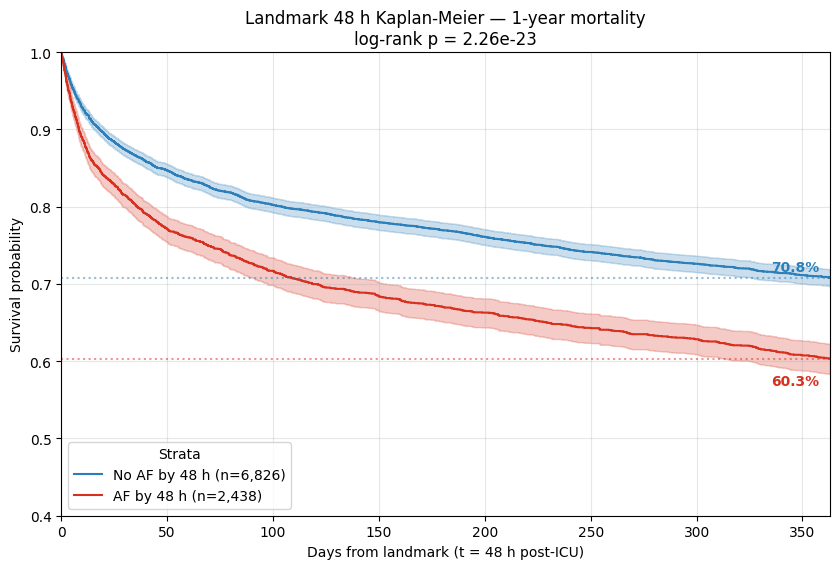

Saved -> revision/figs/km_landmark48h.png


In [20]:
# Fit KM and plot
kmf_af   = KaplanMeierFitter(label=f'AF by 48 h (n={(df_lm["af_by_48h"]==1).sum():,})')
kmf_noaf = KaplanMeierFitter(label=f'No AF by 48 h (n={(df_lm["af_by_48h"]==0).sum():,})')

mask_af = df_lm['af_by_48h'] == 1
kmf_af.fit  (df_lm.loc[ mask_af, '_t'], df_lm.loc[ mask_af, '_e'])
kmf_noaf.fit(df_lm.loc[~mask_af, '_t'], df_lm.loc[~mask_af, '_e'])

lr = logrank_test(df_lm.loc[ mask_af, '_t'], df_lm.loc[~mask_af, '_t'],
                  df_lm.loc[ mask_af, '_e'], df_lm.loc[~mask_af, '_e'])

def km_at(kmf, day):
    sf = kmf.survival_function_
    idx = sf.index.searchsorted(day)
    if idx >= len(sf): idx = len(sf) - 1
    return float(sf.iloc[idx, 0])

s365_af   = km_at(kmf_af,   HORIZON - LM_DAYS)
s365_noaf = km_at(kmf_noaf, HORIZON - LM_DAYS)

print(f'  AF by 48 h:    {s365_af:.1%} survival at {HORIZON} d')
print(f'  No AF by 48 h: {s365_noaf:.1%} survival at {HORIZON} d')
print(f'  Absolute survival difference: {(s365_noaf - s365_af)*100:.1f} pp')
print(f'  Log-rank chi^2 = {lr.test_statistic:.2f}, p = {lr.p_value:.2e}')

fig, ax = plt.subplots(figsize=(8.5, 5.8))
kmf_noaf.plot_survival_function(ax=ax, ci_show=True, color='#2c7fb8')
kmf_af.plot_survival_function  (ax=ax, ci_show=True, color='#d7301f')
ax.axhline(s365_af,   ls=':', color='#d7301f', alpha=0.5)
ax.axhline(s365_noaf, ls=':', color='#2c7fb8', alpha=0.5)
ax.set_xlim(0, HORIZON - LM_DAYS)
ax.set_ylim(0.4, 1.0)
ax.set_xlabel(f'Days from landmark (t = {LM_HOURS} h post-ICU)')
ax.set_ylabel('Survival probability')
ax.set_title(f'Landmark 48 h Kaplan-Meier \u2014 1-year mortality\nlog-rank p = {lr.p_value:.2e}')
ax.legend(loc='lower left', title='Strata')
ax.grid(alpha=0.3)
x_end = HORIZON - LM_DAYS
ax.text(x_end - 5, s365_noaf + 0.005, f'{s365_noaf:.1%}', color='#2c7fb8',
        ha='right', va='bottom', fontsize=10, fontweight='bold')
ax.text(x_end - 5, s365_af   - 0.02,  f'{s365_af:.1%}',   color='#d7301f',
        ha='right', va='top',    fontsize=10, fontweight='bold')
plt.tight_layout()

os.makedirs('revision/figs', exist_ok=True)
fig_path = 'revision/figs/km_landmark48h.png'
plt.savefig(fig_path, dpi=180, bbox_inches='tight')
plt.show()
print(f'Saved -> {fig_path}')

In [21]:
# Number at risk + KM survival summary
risk_times = [0, 60, 120, 180, 240, 300, 365 - LM_DAYS]
def n_at_risk(kmf, t):
    et = kmf.event_table
    return int(et.loc[et.index <= t, 'at_risk'].iloc[-1]) if (et.index <= t).any() else 0

risk_tbl = pd.DataFrame({
    'Days from landmark': [int(t) for t in risk_times],
    'AF by 48 h':         [n_at_risk(kmf_af,   t) for t in risk_times],
    'No AF by 48 h':      [n_at_risk(kmf_noaf, t) for t in risk_times],
})
print('Number at risk table:')
display(risk_tbl)
risk_tbl.to_csv(f'{OUT}/task3_km_n_at_risk.csv', index=False)

km_summary = pd.DataFrame({
    'Days post-landmark': [30, 90, 180, HORIZON - LM_DAYS],
    'AF by 48 h':         [km_at(kmf_af,   d) for d in [30, 90, 180, HORIZON-LM_DAYS]],
    'No AF by 48 h':      [km_at(kmf_noaf, d) for d in [30, 90, 180, HORIZON-LM_DAYS]],
})
km_summary['Absolute diff (pp)'] = (km_summary['No AF by 48 h'] - km_summary['AF by 48 h']) * 100
km_summary['AF by 48 h'] = km_summary['AF by 48 h'].apply(lambda v: f'{v:.1%}')
km_summary['No AF by 48 h'] = km_summary['No AF by 48 h'].apply(lambda v: f'{v:.1%}')
km_summary['Absolute diff (pp)'] = km_summary['Absolute diff (pp)'].apply(lambda v: f'{v:.1f}')
print('KM survival at key timepoints (post-landmark):')
display(km_summary)
km_summary.to_csv(f'{OUT}/task3_km_summary.csv', index=False)

Number at risk table:


,Days from landmark,AF by 48 h,No AF by 48 h
0,0,2438,6826
1,60,1855,5700
2,120,1707,5414
3,180,1636,5253
4,240,1577,5083
5,300,1533,4957
6,363,1471,4833


KM survival at key timepoints (post-landmark):


,Days post-landmark,AF by 48 h,No AF by 48 h,Absolute diff (pp)
0,30.000,81.5%,87.4%,5.9
1,90.000,72.6%,80.8%,8.1
2,180.000,67.0%,76.9%,9.9
3,363.000,60.3%,70.8%,10.5


## Section 11 — Update `data/data.csv` with new variables

Merge the new AF/chronic/timing columns built in this notebook back onto the original `data/data.csv` so downstream code (Task 1 / Task 2 notebooks, future analyses) can read them directly.

**What's added** (existing columns are left untouched for backward compatibility):
- `has_af_chartevents`, `first_af_time`, `hrs_to_first_af`, `n_af_records`, `n_rhythm_records`
- `af_at_admission`, `af_drug_at_admit`, `chronic_af_proxy`, `af_new_onset`
- `days_to_death_clean` (re-computed from authoritative timestamps)
- `death_inhosp` (in-hospital mortality from authoritative deathtime)
- `event_30d`, `event_90d`, `event_180d`, `event_365d` and `t2event_30d`–`t2event_365d`

In [22]:
# Write back updated data.csv
data_path = 'data/data.csv'
orig = pd.read_csv(data_path)
print(f'Original data.csv: {orig.shape}')

# New columns to merge in (keyed by hadm_id)
new_cols = ['hadm_id',
            'has_af_chartevents','first_af_time','hrs_to_first_af',
            'n_af_records','n_rhythm_records',
            'af_at_admission','af_drug_at_admit','chronic_af_proxy','af_new_onset',
            'death_inhosp',
            'event_30d','event_90d','event_180d','event_365d',
            't2event_30d','t2event_90d','t2event_180d','t2event_365d']
extras = df[new_cols].copy()
extras = extras.rename(columns={'death_inhosp':'death_inhosp_clean'})  # avoid clashing with any old name
# Also export days_to_death (re-computed from authoritative dates) under a non-clashing name
extras['days_to_death_clean'] = df['days_to_death']

# Drop any of these columns from orig if they happen to exist already (so merge doesn't duplicate)
for c in extras.columns:
    if c != 'hadm_id' and c in orig.columns:
        orig = orig.drop(columns=[c])

merged = orig.merge(extras, on='hadm_id', how='left')
print(f'Updated data.csv: {merged.shape}  (added {merged.shape[1] - orig.shape[1]} new columns)')
merged.to_csv(data_path, index=False)
print(f'Saved -> {data_path}')

# Print a quick check
print('\nNew column summary:')
for c in [c for c in extras.columns if c != 'hadm_id']:
    if merged[c].dtype.kind in 'biufc':
        print(f'  {c:25s}  mean={merged[c].mean():.3f}  non-null={merged[c].notna().sum():,}')
    else:
        print(f'  {c:25s}  non-null={merged[c].notna().sum():,}')

Original data.csv: (9463, 54)
Updated data.csv: (9463, 73)  (added 19 new columns)


Saved -> data/data.csv

New column summary:
  has_af_chartevents         mean=0.354  non-null=9,463
  first_af_time              non-null=3,346
  hrs_to_first_af            mean=41.479  non-null=3,346
  n_af_records               mean=24.053  non-null=9,463
  n_rhythm_records           mean=132.367  non-null=9,463
  af_at_admission            mean=0.127  non-null=9,463
  af_drug_at_admit           mean=0.024  non-null=9,463
  chronic_af_proxy           mean=0.146  non-null=9,463
  af_new_onset               mean=0.219  non-null=9,463
  death_inhosp_clean         mean=0.125  non-null=9,463
  event_30d                  mean=0.155  non-null=9,463
  event_90d                  mean=0.228  non-null=9,463
  event_180d                 mean=0.271  non-null=9,463
  event_365d                 mean=0.334  non-null=9,463
  t2event_30d                mean=26.927  non-null=9,463
  t2event_90d                mean=75.124  non-null=9,463
  t2event_180d               mean=142.417  non-null=9,463
  t2even